In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print ("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [21]:
df=pd.read_csv("retail_sales.csv")
df = pd.read_csv("retail_sales.csv")

# Fix string-based fake null values
df['Category'] = df['Category'].replace(['Null', 'NaN?', 'Nan', 'null', 'nan', 'NULL'], pd.NA)
df['Region'] = df['Region'].replace(['Null', 'NaN?', 'Nan', 'null', 'nan', 'NULL'], pd.NA)
df.head(10)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,<NA>,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


In [22]:
print("Dataset Basic Information is as follows:")
print(f"{df.shape[0]} rows x {df.shape[1]} columns")
print("columns names and dtypes are as follows:")
print(df.dtypes)

Dataset Basic Information is as follows:
1825 rows x 6 columns
columns names and dtypes are as follows:
Date         object
Category     object
Sales       float64
Quantity    float64
Profit      float64
Region       object
dtype: object


In [23]:
print(df.isnull().sum())
print("Dataset Summary Statistics are as follows:")
print(df.info())


Date        0
Category    7
Sales       2
Quantity    5
Profit      0
Region      6
dtype: int64
Dataset Summary Statistics are as follows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1818 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1819 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB
None


In [24]:
# Handle null values
print("Null values before handling:")
print(df.isnull().sum())

# Fill categorical columns with mode
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])

# Fill numerical columns with median (more robust than mean with outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nNull values after handling:")
print(df.isnull().sum())

Null values before handling:
Date        0
Category    7
Sales       2
Quantity    5
Profit      0
Region      6
dtype: int64

Null values after handling:
Date        0
Category    0
Sales       0
Quantity    0
Profit      0
Region      0
dtype: int64


In [25]:
print("===Data Cleaning and Type Conversion===")
df['Date']=pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.month
df['Quarter']=df['Date'].dt.quarter
df['DayofWeek']=df['Date'].dt.day_name()
df["MonthName"]=df['Date'].dt.month_name()
numeric_cols=['Sales','Profit','Quantity']
for col in numeric_cols:
    df[col]=pd.to_numeric(df[col],errors='coerce')
print("Data types after conversion:")
print(df.dtypes)
print(f"\nDate range:{df['Date'].min()} to {df['Date'].max()}")



===Data Cleaning and Type Conversion===
Data types after conversion:
Date         datetime64[ns]
Category             object
Sales               float64
Quantity            float64
Profit              float64
Region               object
Month                 int32
Quarter               int32
DayofWeek            object
MonthName            object
dtype: object

Date range:2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [26]:
#Basic Statistical Summary
print("===Basic Statistical Summary===")
print("Descriptive statistics for numerical columns:")
print(df[['Sales', 'Profit', 'Quantity']].describe())

===Basic Statistical Summary===
Descriptive statistics for numerical columns:
             Sales       Profit     Quantity
count  1825.000000  1825.000000  1825.000000
mean    980.501573   248.696130    10.053699
std     336.572425   118.159627     5.507806
min       0.000000     0.000000     0.000000
25%     784.267165   156.916498     5.000000
50%     997.725134   229.344557    10.000000
75%    1208.163533   324.867847    15.000000
max    1888.932537   703.228418    19.000000


In [27]:
print("Categorical Summary:")
category_summary=df.groupby('Category').agg({"Sales":['count','sum','mean','median','min','max'], "Profit": ['sum','mean','median','min','max'], "Quantity": ['sum','mean','median','min','max']}).round(2)
print(category_summary)

Categorical Summary:
            Sales                                               Profit  \
            count        sum     mean   median  min      max       sum   
Category                                                                 
Books         364  370971.87  1019.15  1032.94  0.0  1835.18  92304.45   
Clothing      372  358178.75   962.85   991.43  0.0  1763.10  91613.25   
Electronics   361  365088.13  1011.32  1035.06  0.0  1829.79  90439.70   
Home Goods    364  347493.83   954.65   948.28  0.0  1739.26  87447.82   
Sports        364  347682.79   955.17   985.14  0.0  1888.93  92065.22   

                                           Quantity                           
               mean  median    min     max      sum   mean median  min   max  
Category                                                                      
Books        253.58  235.48  22.16  652.84   3737.0  10.27   10.0  1.0  19.0  
Clothing     246.27  226.74   8.14  649.17   3697.0   9.94   10.0  1.0

In [28]:
print("\nRegion-wise Summary:")
region_summary=df.groupby('Region').agg({"Sales":['count','sum','mean','median','min','max'], "Profit": ['sum','mean','median','min','max'], "Quantity": ['sum','mean','median','min','max']}).round(2)
print(region_summary)


Region-wise Summary:
       Sales                                               Profit          \
       count        sum    mean   median  min      max        sum    mean   
Region                                                                      
East     398  394439.34  991.05  1004.86  0.0  1888.93   98973.62  248.68   
North    460  449292.76  976.72   989.89  0.0  1712.24  112126.47  243.75   
South    490  475168.90  969.73   981.83  0.0  1790.06  120252.57  245.41   
West     477  470514.37  986.40  1008.71  0.0  1835.18  122517.78  256.85   

                              Quantity                           
        median    min     max      sum   mean median  min   max  
Region                                                           
East    235.35  39.86  630.17   4123.0  10.36   11.0  1.0  19.0  
North   221.18  21.37  645.71   4699.0  10.22   10.0  1.0  19.0  
South   229.57   8.14  703.23   4848.0   9.89   10.0  1.0  19.0  
West    234.22   0.00  652.84   4678.0   9

In [29]:
print("===Monthly Sales Trend Analysis ===")
monthly_sales=df.groupby(["Month","MonthName"]).agg({"Sales":'sum',"Profit":"sum","Quantity":"sum"}).reset_index()
monthly_sales=monthly_sales.sort_values("Month")
print("Monthly Sales Summary:")
print(monthly_sales)

===Monthly Sales Trend Analysis ===
Monthly Sales Summary:
    Month  MonthName          Sales        Profit  Quantity
0       1    January  149064.069744  39711.436221    1536.0
1       2   February  132215.411776  34353.123612    1517.0
2       3      March  145321.200626  38584.599285    1447.0
3       4      April  138160.991209  37895.203187    1446.0
4       5        May  150774.977103  40527.689566    1603.0
5       6       June  152605.749860  39042.686605    1570.0
6       7       July  162111.115687  40208.956109    1536.0
7       8     August  148020.452251  34675.627875    1489.0
8       9  September  153094.700793  37796.761379    1598.0
9      10    October  151272.280840  36019.384158    1569.0
10     11   November  146795.613628  36344.048332    1461.0
11     12   December  159978.807192  38710.920857    1576.0


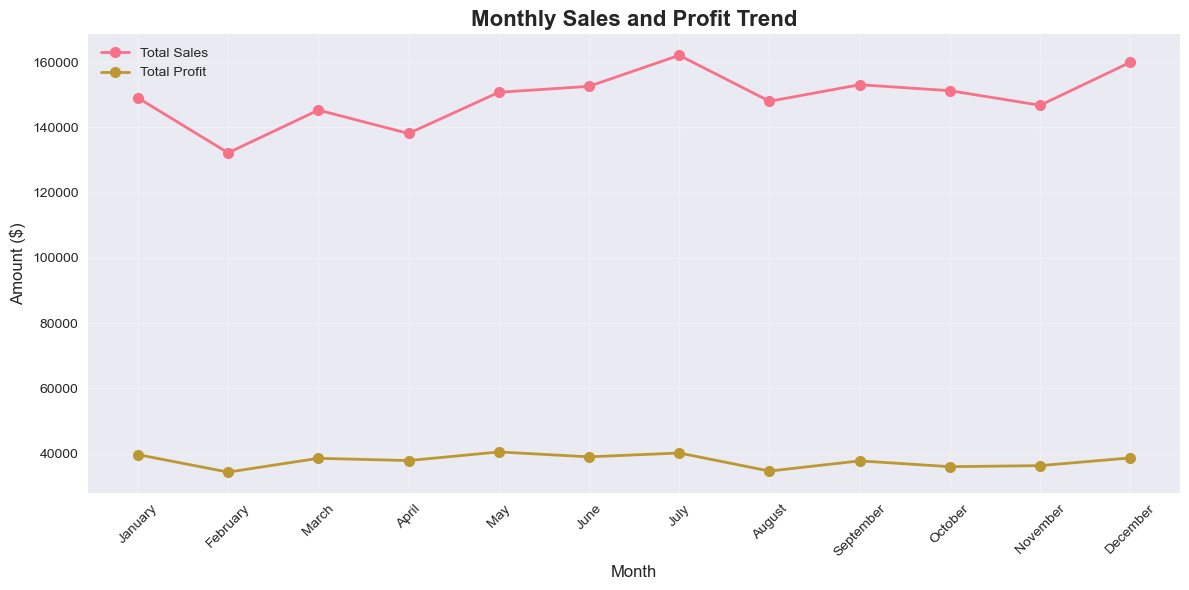

In [30]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales["MonthName"], monthly_sales["Sales"], marker="o",linewidth=2, markersize=8, label='Total Sales')
plt.plot(monthly_sales["MonthName"], monthly_sales["Profit"], marker="o",linewidth=2, markersize=8, label='Total Profit')
plt.xlabel("Month",fontsize=12)
plt.ylabel("Amount ($)",fontsize=12)
plt.title("Monthly Sales and Profit Trend",fontsize=16,fontweight='bold')
plt.legend()
plt.grid(True,alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
print("=== Category Performance Analysis ===")
category_performance=df.groupby('Category').agg({"Sales":'sum',"Profit":"sum","Quantity":"sum"}).sort_values("Sales",ascending=False)
print(category_performance)

=== Category Performance Analysis ===
                     Sales        Profit  Quantity
Category                                          
Books        370971.872558  92304.452141    3737.0
Electronics  365088.131422  90439.697795    3595.0
Clothing     358178.751209  91613.246341    3697.0
Sports       347682.788431  92065.220851    3542.0
Home Goods   347493.827088  87447.820056    3777.0


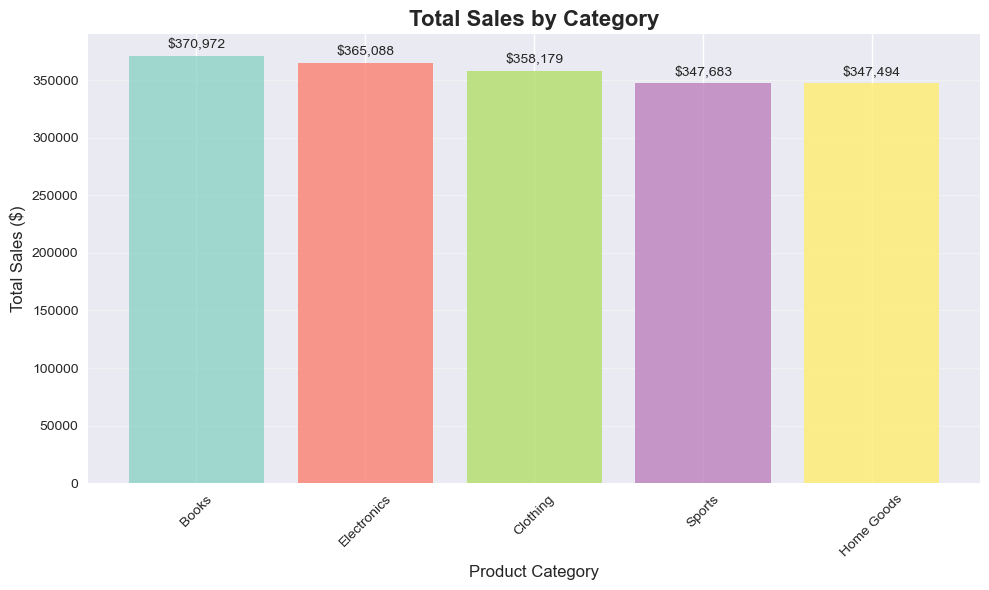

In [32]:
# Visualization 2 :TOp Categories by Sales
plt.figure(figsize=(10,6))
colors=plt.cm.Set3(np.linspace(0,1,len(category_performance)))
bars=plt.bar(category_performance.index, category_performance["Sales"], color=colors,alpha=0.8)
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height*1.01, f"${height:,.0f}", ha='center', va='bottom', fontsize=10)
plt.title("Total Sales by Category",fontsize=16,fontweight='bold')
plt.xlabel("Product Category",fontsize=12)
plt.ylabel('Total Sales ($)',fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
print("=== REGIONAL PERFORMANCE ANALYSIS ===")
regional_performance=df.groupby('Region').agg({"Sales":'sum',"Profit":"sum","Quantity":"sum"}).sort_values("Sales",ascending=False)
print(regional_performance)

=== REGIONAL PERFORMANCE ANALYSIS ===
                Sales         Profit  Quantity
Region                                        
South   475168.903174  120252.570872    4848.0
West    470514.369828  122517.775250    4678.0
North   449292.758063  112126.470662    4699.0
East    394439.339642   98973.620400    4123.0


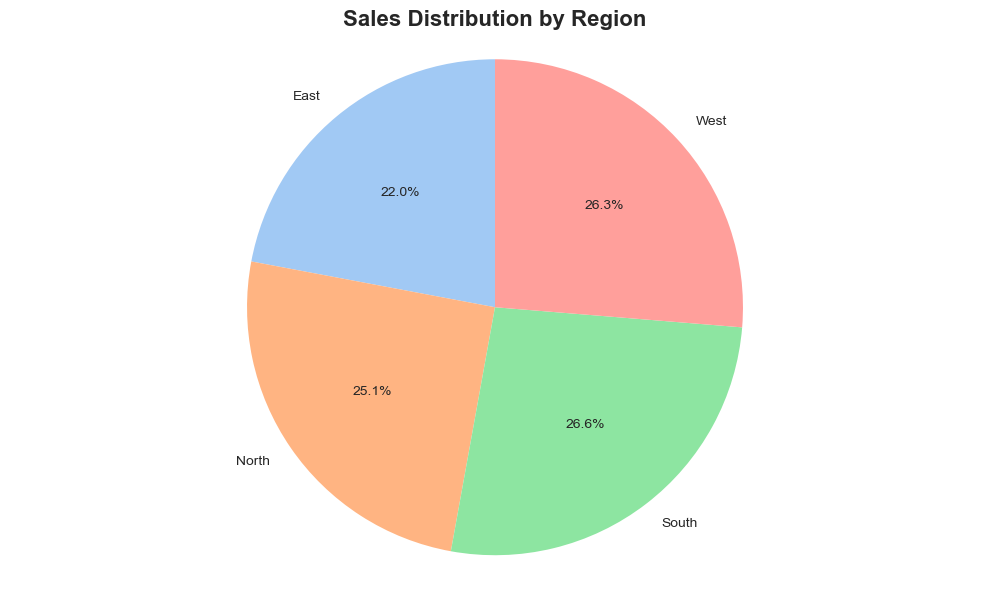

In [34]:
# Visualization 3 : Regional Sales Performance
plt.figure(figsize=(10,6))
regional_data=df.groupby('Region')['Sales'].sum()
plt.pie(regional_data, labels=regional_data.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Sales Distribution by Region",fontsize=16,fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

=== Day of Week Sales Analysis ===
Average Performance by Day of Week:
               Sales    Profit  Quantity
DayofWeek                               
Monday     255260.30  65864.48    2663.0
Tuesday    255330.36  63487.88    2681.0
Wednesday  250959.57  61766.94    2647.0
Thursday   251377.07  61782.06    2542.0
Friday     263721.28  67547.95    2600.0
Saturday   252772.20  65861.96    2507.0
Sunday     259994.59  67559.15    2708.0


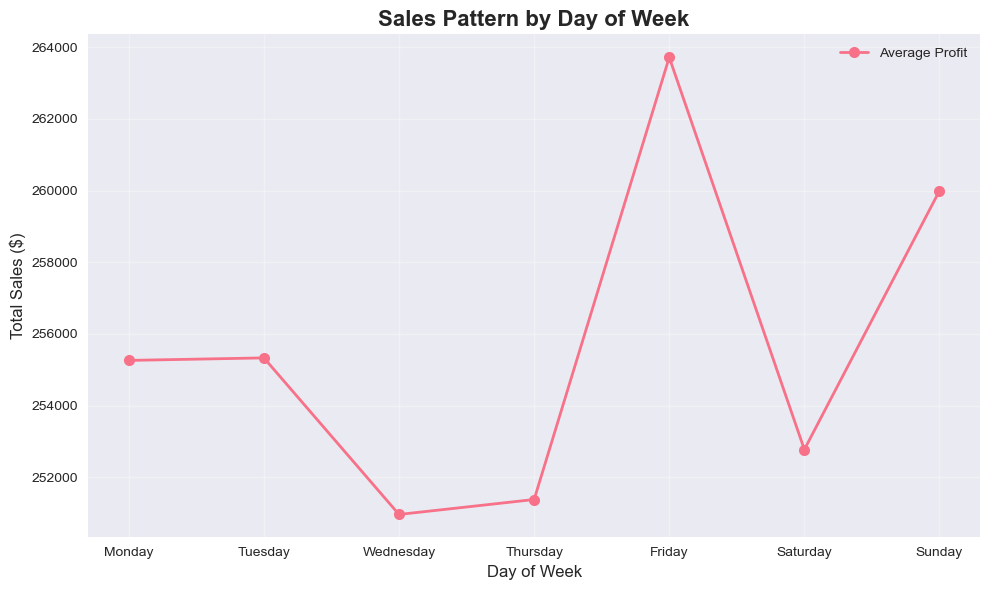

In [35]:
#Day of Week Analysis
print("=== Day of Week Sales Analysis ===")
day_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayofWeek'] = pd.Categorical(df['DayofWeek'], categories=day_order, ordered=True)
daily_performance=df.groupby('DayofWeek').agg({"Sales":'sum',"Profit":"sum","Quantity":"sum"}).round(2)
print("Average Performance by Day of Week:")
print(daily_performance)
#Visualization 4 : Day of Week Sales Pattern
plt.figure(figsize=(10,6))
plt.plot(daily_performance.index, daily_performance["Sales"], marker="o",linewidth=2, markersize=8, label='Average Profit')
plt.title("Sales Pattern by Day of Week",fontsize=16,fontweight='bold')
plt.xlabel("Day of Week",fontsize=12)
plt.ylabel("Total Sales ($)",fontsize=12)
plt.grid(True,alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

=== CORRELATION ANALYSIS ===
Correlation Matrix:
             Sales    Profit  Quantity     Month
Sales     1.000000  0.524104  0.056607  0.065109
Profit    0.524104  1.000000  0.027792 -0.034678
Quantity  0.056607  0.027792  1.000000  0.003159
Month     0.065109 -0.034678  0.003159  1.000000


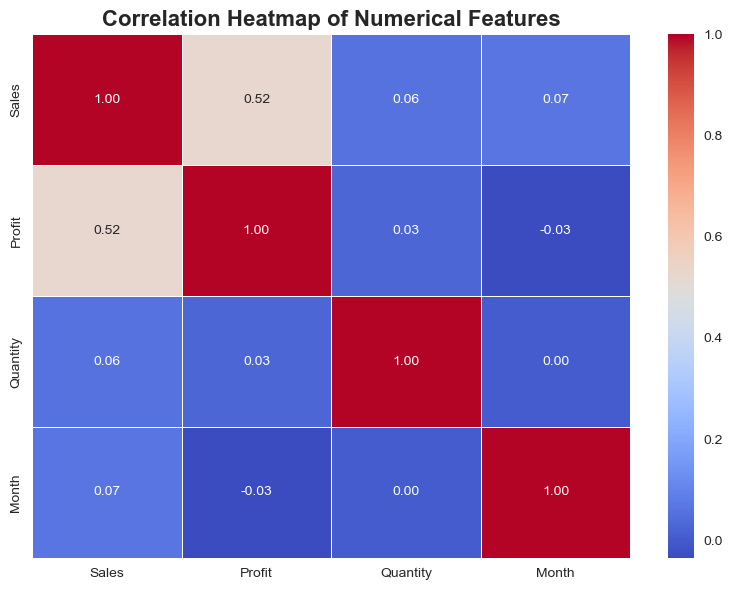

In [36]:
print("=== CORRELATION ANALYSIS ===")
numerical_df=df[['Sales', 'Profit', 'Quantity','Month']]
correlation_matrix=numerical_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)
# Visualization 5 : Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features",fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

=== 4-CHART RETAIL SALES DASHBOARD ===


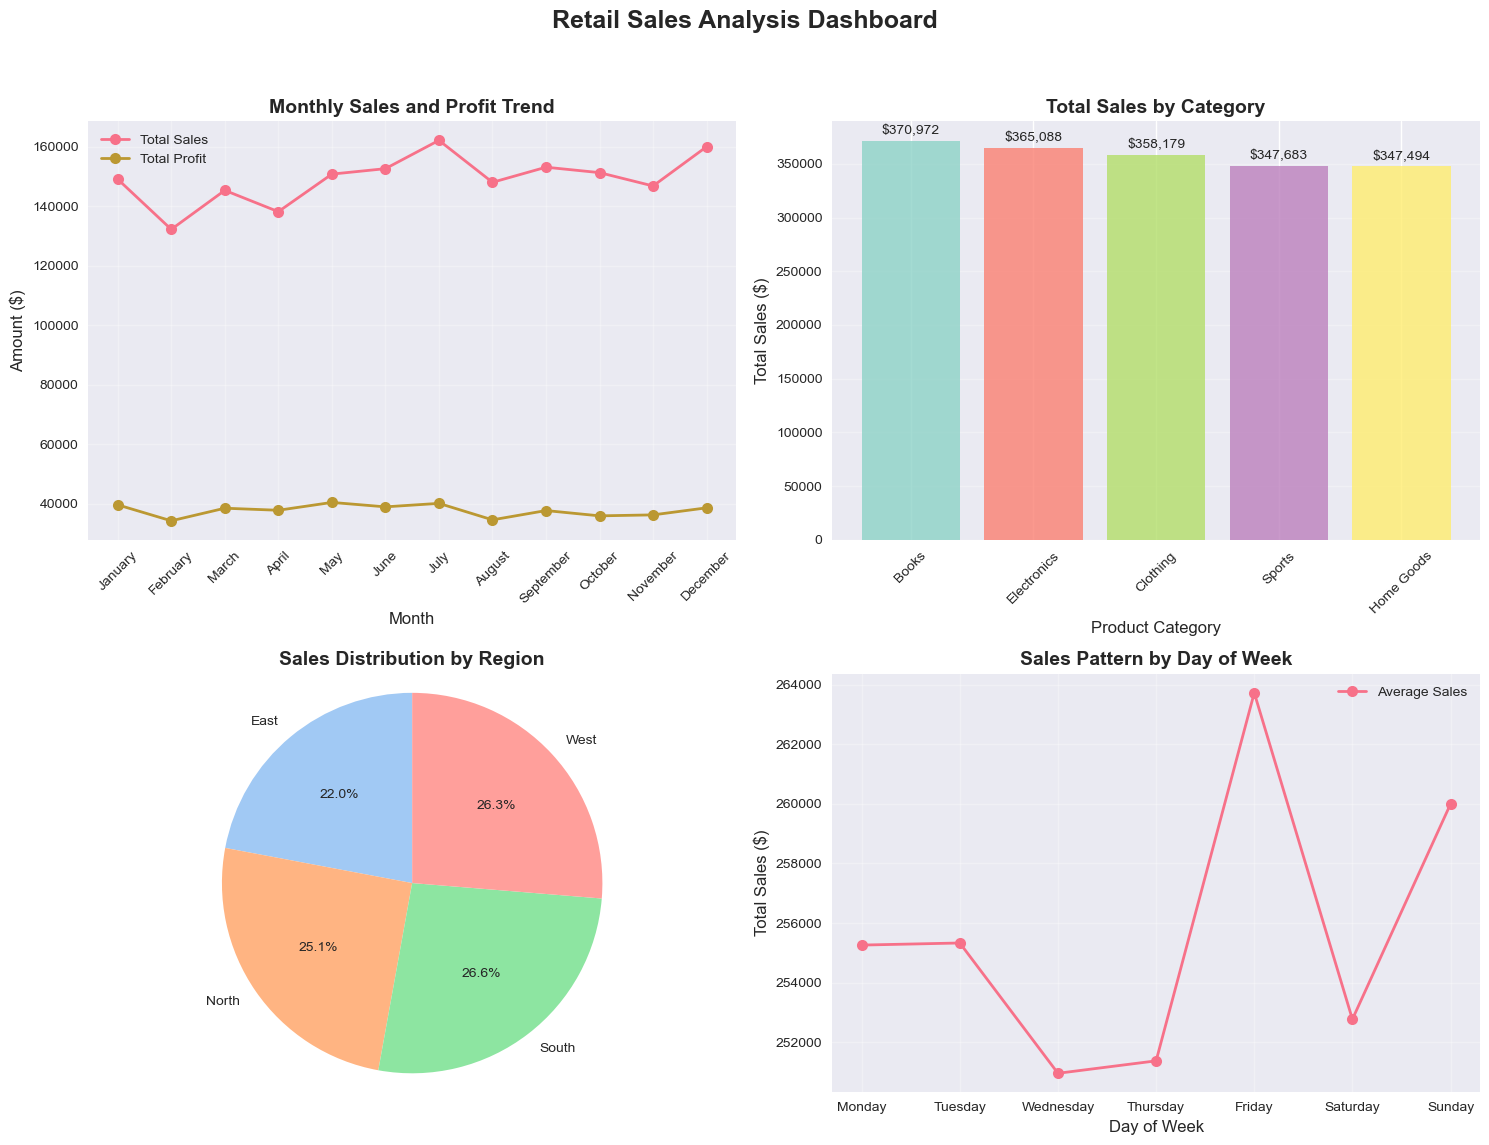

In [37]:
#4_Chart Mini Dashboard
print("=== 4-CHART RETAIL SALES DASHBOARD ===")
fig, axes=plt.subplots(2,2, figsize=(15,12))
fig.suptitle("Retail Sales Analysis Dashboard", fontsize=18, fontweight='bold')
# Chart 1: Monthly Sales Trend
axes[0,0].plot(monthly_sales["MonthName"], monthly_sales["Sales"], marker="o",linewidth=2, markersize=8, label='Total Sales')
axes[0,0].plot(monthly_sales["MonthName"], monthly_sales["Profit"], marker="o",linewidth=2, markersize=8, label='Total Profit')
axes[0,0].set_title("Monthly Sales and Profit Trend", fontsize=14, fontweight='bold')
axes[0,0].set_xlabel("Month",fontsize=12)
axes[0,0].set_ylabel("Amount ($)",fontsize=12)
axes[0,0].legend()
axes[0,0].grid(True,alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)
# Chart 2: Sales by Category
colors=plt.cm.Set3(np.linspace(0,1,len(category_performance)))
bars=axes[0,1].bar(category_performance.index, category_performance["Sales"], color=colors,alpha=0.8)
for bar in bars:
    height=bar.get_height()
    axes[0,1].text(bar.get_x()+bar.get_width()/2, height*1.01, f"${height:,.0f}", ha='center', va='bottom', fontsize=10)
axes[0,1].set_title("Total Sales by Category",fontsize=14,fontweight='bold')
axes[0,1].set_xlabel("Product Category",fontsize=12)
axes[0,1].set_ylabel('Total Sales ($)',fontsize=12)
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)
# Chart 3: Regional Sales Distribution
regional_data=df.groupby('Region')['Sales'].sum()
axes[1,0].pie(regional_data, labels=regional_data.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
axes[1,0].set_title("Sales Distribution by Region",fontsize=14,fontweight='bold')
axes[1,0].axis('equal')
# Chart 4: Sales Pattern by Day of Week
axes[1,1].plot(daily_performance.index, daily_performance["Sales"], marker="o",linewidth=2, markersize=8, label='Average Sales')
axes[1,1].set_title("Sales Pattern by Day of Week",fontsize=14,fontweight='bold')
axes[1,1].set_xlabel("Day of Week",fontsize=12)
axes[1,1].set_ylabel("Total Sales ($)",fontsize=12)
axes[1,1].grid(True,alpha=0.3)
axes[1,1].legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [38]:
#Key Insights and Recommendations
print("=== Key Insights and Recommendations ===")
print("\n 📊 Key Findings:")
print("1.Top Performing Product Category: ", category_performance.index[0])
print("Best Performing Region", regional_data.idxmax())
print("3.Highest Sales Month:",monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'MonthName'])
print("4. Best Day of Week",daily_performance['Sales'].idxmax())
print("5. Total Annual Sales: ${:,.2f}".format(df['Sales'].sum()))
print("6. Total Annual Profit: ${:,.2f}".format(df['Profit'].sum()))

print("\n💡 BUSINESS RECOMMENDATIONS:")
print("1. 🎯 Focus marketing efforts on", category_performance.index[0], "category")
print("2. 🔎 Investigate performance in lower-performing regions")
print("3. 📢 Plan promotions around", daily_performance['Sales'].idxmax(), "to maximize sales")
print("4. 📦 Allocate inventory based on monthly trend patterns")
print("5. 📊 Monitor correlation between quantity and profit for pricing strategy")

print("\n💰 PROFITABILITY ANALYSIS:")
profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100
print(f"📊 Overall Profit Margin: {profit_margin:.2f}%")

# Category profit margins
category_margins = (category_performance['Profit'] / category_performance['Sales']) * 100
print("\n📈 Profit Margins by Category:")
for category, margin in category_margins.items():
    print(f"   {category}: {margin:.2f}%")


=== Key Insights and Recommendations ===

 📊 Key Findings:
1.Top Performing Product Category:  Books
Best Performing Region South
3.Highest Sales Month: July
4. Best Day of Week Friday
5. Total Annual Sales: $1,789,415.37
6. Total Annual Profit: $453,870.44

💡 BUSINESS RECOMMENDATIONS:
1. 🎯 Focus marketing efforts on Books category
2. 🔎 Investigate performance in lower-performing regions
3. 📢 Plan promotions around Friday to maximize sales
4. 📦 Allocate inventory based on monthly trend patterns
5. 📊 Monitor correlation between quantity and profit for pricing strategy

💰 PROFITABILITY ANALYSIS:
📊 Overall Profit Margin: 25.36%

📈 Profit Margins by Category:
   Books: 24.88%
   Electronics: 24.77%
   Clothing: 25.58%
   Sports: 26.48%
   Home Goods: 25.17%
